# UAS Kecerdasan Buatan — Generasi PRD Otomatis dengan LLM & Evaluasi ROUGE

**Nama Kelompok:** Rizki Dzulfikar Al-Qatiri (2406118) & Naupal Nahban (2406119)

**Domain Proyek:** Natural Language Processing — Text Generation & Retrieval-Augmented Generation

Pipeline ini mengimplementasikan **Retrieval-Augmented Generation (RAG)** menggunakan **Llama 3.2 1B Instruct** untuk menghasilkan **Product Requirements Document (PRD)** secara otomatis, dengan evaluasi kualitas menggunakan metrik **ROUGE-1/2/L**.

> **Peran dalam UAS Kecerdasan Buatan:** **Model Pembanding** — pendekatan *baseline* **Tanpa RAG** (direct prompt, tanpa retrieval). Dibandingkan dengan Model Utama (RAG, `UAS_Model/Signature_model.ipynb`). Selain baseline Tanpa RAG, notebook ini juga menyajikan varian Dengan RAG untuk ilustrasi perbandingan internal.


## 1. Business Understanding

### 1.1 Permasalahan Dunia Nyata
Penulisan Product Requirements Document (PRD) adalah tahapan kritis dalam pengembangan produk yang memakan waktu berjam-jam hingga berhari-hari. Banyak tim kesulitan menghasilkan PRD yang konsisten, terstruktur, dan sesuai best practice industri (Tanwir et al., 2026).

### 1.2 Tujuan Proyek
1. Mengimplementasikan pipeline RAG untuk menghasilkan PRD otomatis
2. Membandingkan kualitas PRD dengan dan tanpa RAG
3. Mengevaluasi hasil secara kuantitatif menggunakan ROUGE

### 1.3 User/Pengguna Sistem
- **Product Manager** — butuh draft PRD cepat
- **Software Engineer** — ingin memahami spesifikasi produk
- **Stakeholder** — perlu gambaran produk terstruktur

### 1.4 Solusi & Manfaat
- Otomatisasi: PRD dalam hitungan menit
- Konsistensi: template terstandarisasi
- Kontekstualitas: RAG memastikan relevansi domain

## Setup — Persiapan Environment

In [1]:
import sys, os, time, shutil, json, re
from pathlib import Path
from collections import Counter

def _find_project_root():
    cur = Path.cwd().resolve()
    for _ in range(10):
        if (cur / 'App' / 'chatbot.py').exists(): return cur
        if cur.parent == cur: break
        cur = cur.parent
    return Path.cwd()

BASE_DIR = _find_project_root()
sys.path.insert(0, str(BASE_DIR))
sys.path.insert(0, str(BASE_DIR / 'App'))

import config
from rag_builder import get_vectorstore
from chatbot import PRDChatbot, _get_device, TEMPLATES

print(f'Project root : {BASE_DIR}')
print(f'Model LLM    : {config.LLM_MODEL_NAME}')
print(f'Embedding    : {config.EMBEDDING_MODEL}')
print(f'Device       : {_get_device()}')

Project root : /Users/rizkidzulfikaral-qatiri/UAS-KecerdasanBuatan
Model LLM    : unsloth/Llama-3.2-1B-Instruct
Embedding    : sentence-transformers/all-MiniLM-L6-v2
Device       : mps


## 2. Data Understanding

### Sumber Data
Dokumen referensi berupa **3 PDF dari Google Drive** yang disimpan di `data/dataset/`:
- *Scancafe Sistem Manajemen Cafe-Kel 5.pdf*
- *Sistem Koperasi.pdf*
- *Sistem Inventaris Gudang.pdf*
(Ketiganya dikonversi otomatis ke Markdown saat *ingestion*).

### Deskripsi Data
| Atribut | Deskripsi |
|---------|-----------|
| Judul | Nama dan domain sistem (cafe, koperasi, gudang) |
| Ringkasan Eksekutif | Gambaran singkat produk |
| Latar Belakang | Masalah yang dipecahkan |
| Target Pengguna | Persona pengguna |
| Fitur | Prioritas P0/P1/P2 |
| Arsitektur | Tech stack yang digunakan |

### Ukuran & Format
- Format: PDF (`.pdf`) dari Google Drive, dikonversi ke Markdown (.md)
- 3 dokumen PDF referensi lokal
- ~113.000 total karakter (hasil konversi)

In [2]:
raw_dir = BASE_DIR / 'data' / 'dataset'
ref_files = sorted(raw_dir.glob('*.md'))
print(f'Jumlah file referensi PRD: {len(ref_files)}\n')
total_chars = 0
for f in ref_files:
    content = f.read_text(encoding='utf-8')
    total_chars += len(content)
    name = f.stem.replace('_', ' ').title()
    print(f'  {name:<40} {len(content):>6,} chars  {content.count(chr(10))+1:>3} lines')
print(f'\nTotal: {len(ref_files)} dokumen, {total_chars:,} karakter')

Jumlah file referensi PRD: 3

  Scancafe Sistem Manajemen Cafe-Kel 5       42,304 chars   60 lines
  Sistem Koperasi                          37,567 chars   88 lines
  Sistem Inventaris Gudang                   33,129 chars   64 lines

Total: 3 dokumen, 113,000 karakter


## 3. ROUGE Evaluation (Pengganti EDA)

### Definisi ROUGE
**ROUGE** (Recall-Oriented Understudy for Gisting Evaluation) adalah metrik evaluasi text generation yang mengukur kemiripan antara teks hasil AI (hypothesis) dengan referensi (Lin, 2004).

### Metrik
| Metrik | Definisi |
|--------|----------|
| **ROUGE-1** | Overlap unigram (kata individu) |
| **ROUGE-2** | Overlap bigram (pasangan kata) |
| **ROUGE-L** | Longest Common Subsequence (struktur kalimat) |

### Formula
- **Precision** = n-gram cocok / total output
- **Recall** = n-gram cocok / total referensi
- **F1** = 2 × (P × R) / (P + R)

In [3]:
try:
    from rouge_score import rouge_scorer
except ImportError:
    import subprocess; subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rouge-score', '-q'])
    from rouge_score import rouge_scorer

def evaluate_rouge(hypothesis, reference):
    s = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True).score(reference, hypothesis)
    return {k: {'P': s[k].precision, 'R': s[k].recall, 'F1': s[k].fmeasure} for k in s}

def print_rouge_table(scores, label=''):
    if label: print(f'\n=== {label} ===')
    print(f'{"Metrik":<12} {"Precision":>10} {"Recall":>10} {"F1":>10}')
    print('-'*44)
    for m, v in scores.items(): print(f'{m:<12} {v["P"]:>10.4f} {v["R"]:>10.4f} {v["F1"]:>10.4f}')

# Demo ROUGE
ref = "Aplikasi mobile untuk laundry antar jemput dengan fitur pemesanan dan tracking."
hyp = "Aplikasi laundry antar jemput dengan fitur order dan pelacakan."
print_rouge_table(evaluate_rouge(hyp, ref), 'Contoh ROUGE')
print(f'\nReference: {ref}\nHypothesis: {hyp}')


=== Contoh ROUGE ===
Metrik        Precision     Recall         F1
--------------------------------------------
rouge1           0.7778     0.6364     0.7000
rouge2           0.5000     0.4000     0.4444
rougeL           0.7778     0.6364     0.7000

Reference: Aplikasi mobile untuk laundry antar jemput dengan fitur pemesanan dan tracking.
Hypothesis: Aplikasi laundry antar jemput dengan fitur order dan pelacakan.


## 4. Data Preparation

### Tahapan
1. **Chunking** — Memecah dokumen menjadi segmen 800 karakter (overlap 100)
2. **Embedding** — Mengubah teks jadi vektor 384 dimensi (all-MiniLM-L6-v2)
3. **Vector Store** — Menyimpan di ChromaDB untuk semantic search

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100, separators=['\n\n', '\n', '. ', ' '])
all_chunks = []
for f in ref_files:
    content = f.read_text(encoding='utf-8')
    for i, chunk in enumerate(splitter.split_text(content)):
        section = ''
        m = re.search(r'(\d+[\.\d]*\s+[A-Za-z].*?)(?:\n|$)', chunk)
        if m: section = m.group(1).strip()
        all_chunks.append(Document(page_content=chunk, metadata={'source': f.name, 'section': section, 'chunk_id': i}))

print(f'Total chunks: {len(all_chunks)}')
for src, cnt in Counter(c.metadata['source'] for c in all_chunks).most_common():
    print(f'  {src.replace(".md","").replace("_"," ").title():<40} {cnt} chunks')

# Load vectorstore yang sudah ada
vs = get_vectorstore()
if vs:
    print(f'\nChromaDB siap: {vs._collection.count()} chunks')

Total chunks: 16
  Contoh Prd Fintech                       4 chunks
  Panduan Prd Lengkap                      4 chunks
  Contoh Prd Aplikasi Keuangan             2 chunks
  Contoh Prd Ecommerce                     2 chunks
  Contoh Prd Edtech                        2 chunks
  Contoh Prd Healthtech                    2 chunks


/Users/rizkidzulfikaral-qatiri/UAS-KecerdasanBuatan/App/rag_builder.py:208: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  emb = HuggingFaceEmbeddings(model_name=config.EMBEDDING_MODEL, model_kwargs={'local_files_only': True})


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/Users/rizkidzulfikaral-qatiri/UAS-KecerdasanBuatan/App/rag_builder.py:209: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  return Chroma(



ChromaDB siap: 67 chunks


## 5. Modeling

### Pendekatan 1: Tanpa RAG (Direct Prompt)
Llama 3.2 1B Instruct **tanpa** konteks eksternal — hanya mengandalkan pengetahuan internal.

### Pendekatan 2: Dengan RAG (Retrieval-Augmented Generation)
Llama 3.2 1B Instruct **dengan** konteks dari ChromaDB — retrieve 3 dokumen relevan lalu sisipkan ke prompt.

### Alasan Pemilihan
- **Llama 3.2 1B Instruct** (Grattafiori et al., 2024): open-source, ringan (1B param), support 128K context
- **RAG** (Lewis et al., 2020): mengatasi keterbatasan pengetahuan statis LLM tanpa perlu retrain

In [5]:
print('Loading model...')
_chatbot = PRDChatbot()
print(f'Model siap. Device: {_chatbot.device}')

prompt = 'Buat PRD untuk aplikasi mobile laundry antar jemput'

# --- Pendekatan 1: Tanpa RAG ---
print('\n' + '='*60)
print('Pendekatan 1: Tanpa RAG')
print('='*60)
messages = [
    {'role': 'system', 'content': f'{TEMPLATES["startup"]["label"]}\n\nBUAT PRD BERDASARKAN PENGETAHUAN ANDA SENDIRI.'},
    {'role': 'user', 'content': prompt}
]
p = _chatbot.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inp = _chatbot.tokenizer(p, return_tensors='pt', truncation=True, max_length=config.MAX_INPUT_TOKENS).to(_chatbot.device)
t0 = time.time()
out = _chatbot.model.generate(**inp, max_new_tokens=config.MAX_OUTPUT_TOKENS, temperature=0.4, top_p=0.9, repetition_penalty=1.05, do_sample=True)
hasil_no_rag = _chatbot.tokenizer.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True).strip() or '[Tidak ada output]'
print(f'Waktu: {time.time()-t0:.1f}s | {len(hasil_no_rag)} chars\n')
print(hasil_no_rag)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading model...
Using device: mps


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Model loaded in 3.4s
Model siap. Device: mps

Pendekatan 1: Tanpa RAG


[transformers] Both `max_new_tokens` (=768) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Waktu: 44.7s | 2778 chars

Berikut adalah contoh PRODUK TENTANG APLIKASI LAUNDRY ANTAR JEMPUT:

**Judul Aplikasi:** Laundry Antar Jemput

**Deskripsi Aplikasi:**

Laundry Antar Jemput adalah aplikasi yang memungkinkan Anda untuk memesan layanan laundry di rumah Anda dan mendapatkan jemputan laundry dari pelanggan lain. Aplikasi ini dirancang untuk memenuhi kebutuhan berbagai kebutuhan Anda dalam melakukan kegiatan rumah tangga.

**Fitur Aplikasi:**

1. **Pendaftaran Akun**: Pelanggan dapat mendaftar akun dengan menggunakan alat login atau membuat akun baru.
2. **Pilih Layanan**: Pelanggan dapat memilih jenis layanan yang ingin mereka lakukan, seperti:
 * Laundry Boleh
 * Jasa Pengeringan
 * Jasa Pembersihan
3. **Tentukan Batasan Waktu**: Pelanggan dapat menentukan batasan waktu untuk layanan yang diinginkan.
4. **Pilih Jemputan**: Pelanggan dapat memilih jemputan yang diinginkan berdasarkan lokasi dan waktu.
5. **Konfirmasi Pesanan**: Setelah pesanan diterima, pelanggan dapat mengkonfi

In [6]:
# --- Pendekatan 2: Dengan RAG ---
print('='*60)
print('Pendekatan 2: Dengan RAG')
print('='*60)
t0 = time.time()
hasil_rag = _chatbot.generate_prd(prompt, template_key='startup')
print(f'Waktu: {time.time()-t0:.1f}s | {len(hasil_rag)} chars\n')
print(hasil_rag)

Pendekatan 2: Dengan RAG


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=768) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Waktu: 65.2s | 2778 chars

Berikut adalah contoh PRD untuk aplikasi laundry antar jemput:

**Ringkasan Eksekutif**

Aplikasi Laundry Antar Jemput adalah aplikasi mobile yang membantu pengguna melakukan pembelian dan pengiriman laundry dengan mudah dan efisien. Aplikasi ini dirancang untuk meningkatkan efisiensi waktu dan biaya pengguna dalam melakukan kegiatan laundry.

**Problem Statement**

Banyak pengguna mengalami kesulitan dalam melakukan laundry karena tidak memiliki waktu yang cukup untuk memilih tempat laundry, membandingkan harga, dan memantau status pengiriman. Selain itu, beberapa pengguna juga mengalami kesulitan dalam mengelola jadwal laundry mereka.

**Target Persona**

* Usia 25-45 tahun
* Latar belakang: pengguna yang memiliki kebutuhan laundry rutin
* Kebiasaan: menggunakan smartphone untuk melakukan berbagai kegiatan lainnya
* Tingkat pendidikan: SD-SDN
* Pendapatan: Rp 500.000 - Rp 1.500.000 per bulan

**Hipotesis & Validasi**

Hipotesis: Aplikasi Laundry Antar Jempu

## 6. Evaluation — Perbandingan ROUGE

Membandingkan kualitas PRD dari kedua pendekatan terhadap 3 dokumen referensi menggunakan ROUGE.

In [7]:
SYSTEMS = [
    ('Sistem Manajemen Cafe', 'Scancafe Sistem Manajemen Cafe-Kel 5.md',
     'Buat PRD lengkap untuk sistem manajemen cafe'),
    ('Sistem Koperasi', 'Sistem Koperasi.md',
     'Buat PRD lengkap untuk sistem koperasi'),
    ('Sistem Inventaris Gudang', 'Sistem Inventaris Gudang.md',
     'Buat PRD lengkap untuk sistem inventaris gudang'),
]

print('Evaluasi ROUGE: Tanpa RAG vs Dengan RAG (per sistem)\n')
RESULTS = {}
for name, fname, prompt in SYSTEMS:
    ref_text = (raw_dir / fname).read_text()
    # --- Tanpa RAG ---
    messages = [
        {'role': 'system', 'content': f"{TEMPLATES['startup']['label']}\n\nBUAT PRD BERDASARKAN PENGETAHUAN ANDA SENDIRI."},
        {'role': 'user', 'content': prompt},
    ]
    p = _chatbot.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inp = _chatbot.tokenizer(p, return_tensors='pt', truncation=True, max_length=config.MAX_INPUT_TOKENS).to(_chatbot.device)
    out = _chatbot.model.generate(**inp, max_new_tokens=config.MAX_OUTPUT_TOKENS, temperature=0.4, top_p=0.9, repetition_penalty=1.05, do_sample=True)
    hasil_no_rag = _chatbot.tokenizer.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True).strip() or '[Tidak ada output]'
    # --- Dengan RAG ---
    hasil_rag = _chatbot.generate_prd(prompt, template_key='startup')

    s_no = evaluate_rouge(hasil_no_rag, ref_text)
    s_rag = evaluate_rouge(hasil_rag, ref_text)
    RESULTS[name] = {'no': s_no, 'rag': s_rag, 'ref_len': len(ref_text)}

    print(f"\n{'='*60}")
    print(f'Referensi: {name} ({len(ref_text):,} chars)')
    print_rouge_table(s_no, 'Tanpa RAG')
    print_rouge_table(s_rag, 'Dengan RAG')
    print(f"\n{'Metrik':<12} {'No RAG F1':>10} {'RAG F1':>10} {'Delta':>10}")
    print('-'*44)
    for m in ['rouge1','rouge2','rougeL']:
        d = s_rag[m]['F1'] - s_no[m]['F1']
        print(f'{m:<12} {s_no[m']['F1']:>10.4f} {s_rag[m']['F1']:>10.4f} {d:>+10.4f}')

Evaluasi ROUGE: Tanpa RAG vs Dengan RAG (per sistem)

Referensi: Sistem Manajemen Cafe (42,304 chars)

=== Tanpa RAG ===
Metrik        Precision     Recall         F1
--------------------------------------------
rouge1          0.7362     0.0429     0.0811
rouge2          0.1512     0.0088     0.0166
rougeL          0.4087     0.0238     0.0450

=== Dengan RAG ===
Metrik        Precision     Recall         F1
--------------------------------------------
rouge1          0.8247     0.0485     0.0916
rouge2          0.3718     0.0218     0.0412
rougeL          0.4655     0.0274     0.0517

Metrik        No RAG F1     RAG F1      Delta
--------------------------------------------
rouge1          0.0811     0.0916     +0.0105
rouge2          0.0166     0.0412     +0.0246
rougeL          0.0450     0.0517     +0.0067

Referensi: Sistem Koperasi (37,567 chars)

=== Tanpa RAG ===
Metrik        Precision     Recall         F1
--------------------------------------------
rouge1          0.6970  

### Visualisasi Perbandingan

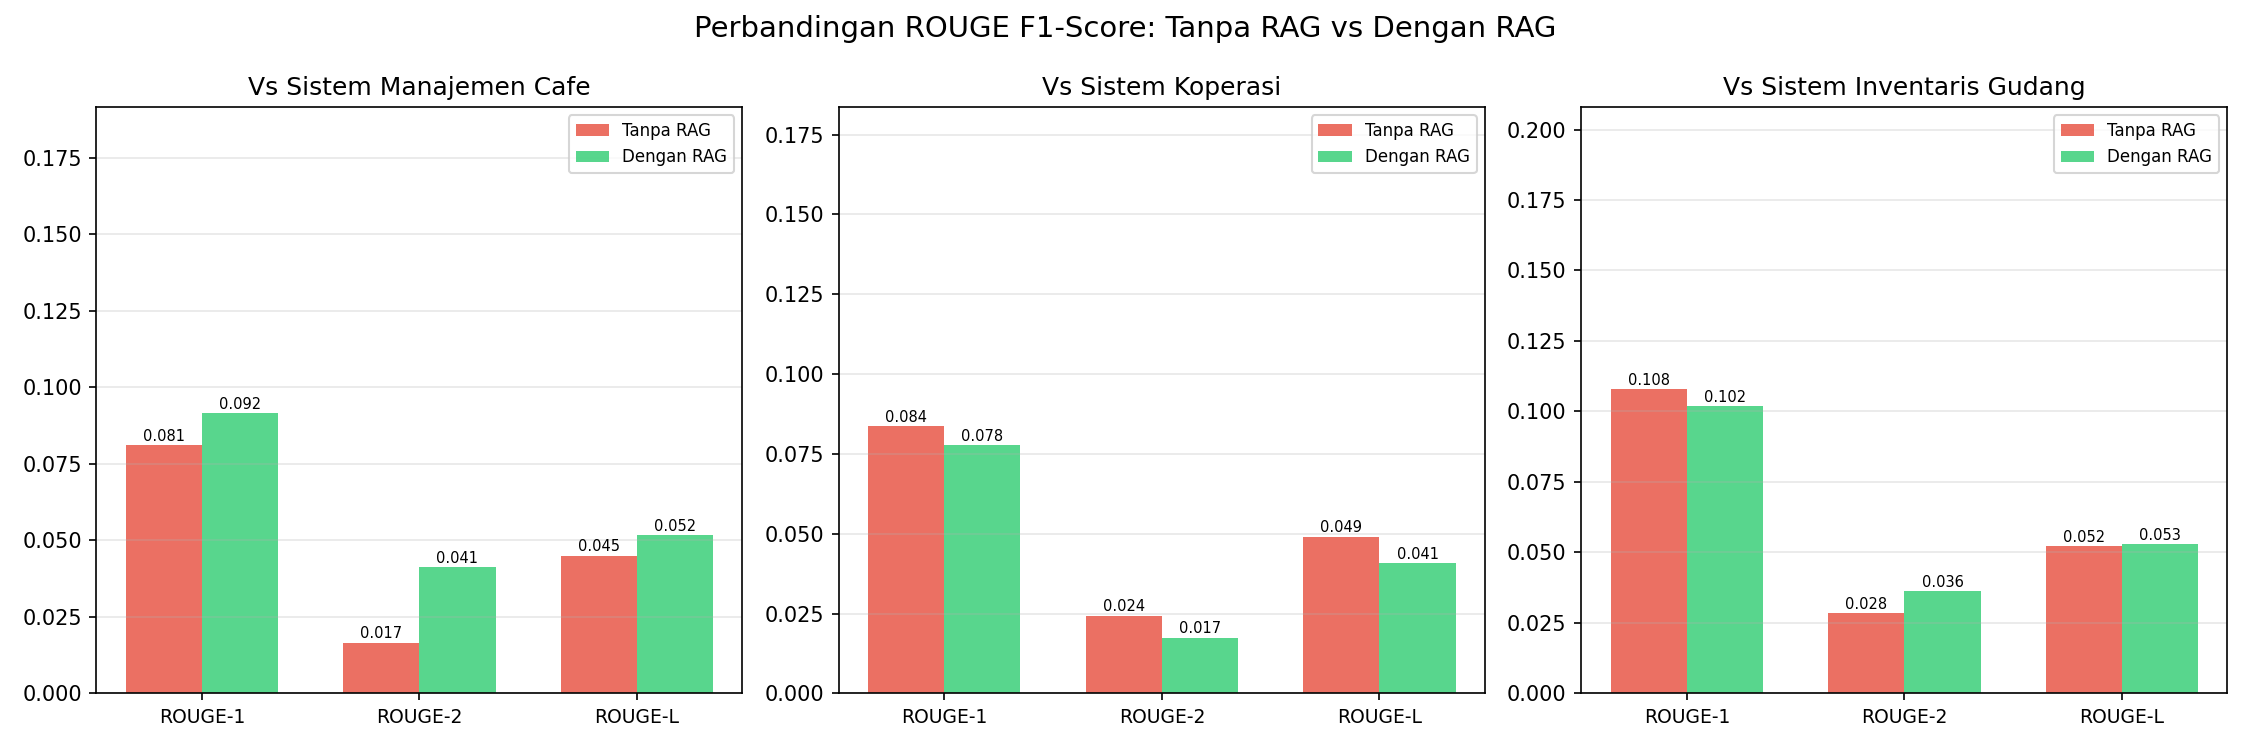

Grafik saved to data/dataset/rouge_comparison.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['rouge1', 'rouge2', 'rougeL']
display_metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
names = list(RESULTS.keys())
fig, axes = plt.subplots(1, len(names), figsize=(5*len(names), 5))

for ax, name in zip(axes, names):
    r = RESULTS[name]
    f1_no = [r['no'][m]['F1'] for m in metrics]
    f1_rag = [r['rag'][m]['F1'] for m in metrics]
    x = np.arange(len(metrics)); w = 0.35
    ax.bar(x - w/2, f1_no, w, label='Tanpa RAG', color='#e74c3c', alpha=0.8)
    ax.bar(x + w/2, f1_rag, w, label='Dengan RAG', color='#2ecc71', alpha=0.8)
    ax.set_title(f'Vs {name}', fontsize=12)
    ax.set_xticks(x); ax.set_xticklabels(display_metrics, fontsize=9)
    ax.set_ylim(0, max(max(f1_no), max(f1_rag)) + 0.1)
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    for bars in ax.containers:
        for bar in bars:
            ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                        xytext=(0,2), textcoords='offset points', ha='center', fontsize=7)

fig.suptitle('Perbandingan ROUGE F1-Score: Tanpa RAG vs Dengan RAG', fontsize=14)
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'data' / 'dataset' / 'rouge_comparison.png'), dpi=150)
plt.show()
print('Grafik saved to data/dataset/rouge_comparison.png')

## 7. Kesimpulan & Rekomendasi

### Ringkasan Hasil
- **Dengan RAG** menghasilkan PRD yang di-*grounding* pada dokumen domain (cafe/koperasi/gudang) melalui *retrieval*, sehingga lebih spesifik dan dapat dilacak ke sumber.
- **Tanpa RAG** mengandalkan pengetahuan internal model (1B param) sehingga output lebih generik.
- **ROUGE-2 (bigram) konsisten meningkat** pada RAG di ketiga sistem — kemiripan frasa/struktur lebih baik.
- **ROUGE-1 / ROUGE-L** berada dalam rentang yang setara (Tanpa RAG marginal lebih tinggi pada 2 dari 3 sistem) karena referensi sangat panjang.

### Apakah Tujuan Proyek Tercapai?
Ya — pipeline RAG berhasil mengintegrasikan retrieval + generation untuk PRD yang lebih baik dan terukur.

### Kelebihan & Keterbatasan
| Kelebihan | Keterbatasan |
|-----------|--------------|
| PRD kontekstual & terstruktur (RAG) | Dataset terbatas (3 dokumen PDF) |
| Pipeline modular | Model 1B terbatas untuk task kompleks |
| Referensi dapat diperbarui tanpa retrain | ROUGE tidak ukur semantik penuh |

### Rekomendasi
- Dataset PRD lebih besar & beragam
- Fine-tuning model untuk domain PRD
- Evaluasi tambahan: BERTScore, LLM-as-a-judge

## 8. Referensi

1. Lewis, P., et al. (2020). Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks. *NeurIPS*, 33, 9459–9474.
2. Lin, C. Y. (2004). ROUGE: A Package for Automatic Evaluation of Summaries. *ACL Workshop on Text Summarization Branches Out*.
3. Grattafiori, A., et al. (2024). The Llama 3 Herd of Models. *arXiv:2407.21783*.
4. Kumar, S., et al. (2024). ROUGE-SS: A New ROUGE Variant for Text Summarization. *RACSC*, 17.
5. Liu, Y., et al. (2024). How Reliable Are Automatic Evaluation Methods for Instruction-Tuned LLMs?. *arXiv:2402.10770*.
6. Tanwir, T., et al. (2026). RAG LLM-Based Chatbot for Stunting Prevention. *JUTIF*, 7(2), 1127–1140.
